In [2]:
import pandas as pd

from lib.h_ensemble import build_ensemble_csv
from lib.plots import plot_uncertainty_distributions, plot_combined_uncertainty_analysis
from lib.utils import compute_uncertainties
import numpy as np
# load data 
""" MAIN SETTINGS AND DATA LOADING"""

dataset = 'ms_neuro'
analysis_name = 'ms_progression'
outcome_name = 'progression_independent_from_relapses'
build_ensemble_csv(analysis_name, outcome_name)


all_patients = pd.read_csv(f'../data/{dataset}/X.csv')
all_patients_y = pd.read_csv(f'../data/{dataset}/y.csv')

all_patients['label'] = all_patients_y[outcome_name].astype(int)


# load all predictions for the full training set (including active patients at bl)
patients_stats = pd.read_csv(f'../results/classification/{analysis_name}/{outcome_name}/aggregated/patient_mean_probs_{outcome_name}_{analysis_name}_model.csv')
patients_stats.index = patients_stats['idx']



# 1. Extract the inner list from each row using .str[0]
import ast

# 1. Convert the string representation "[0.8, 0.83...]" into a real Python list
real_lists = patients_stats['all_probs'].apply(ast.literal_eval)

# 2. Now expand those lists into columns
probs_raw_df = pd.DataFrame(real_lists.tolist(), index=patients_stats['idx'].values)

Successfully aggregated 30240 predictions across 719 unique patients.


## Uncertainty Decomposition

Baseline entropy: 0.5120043783280033


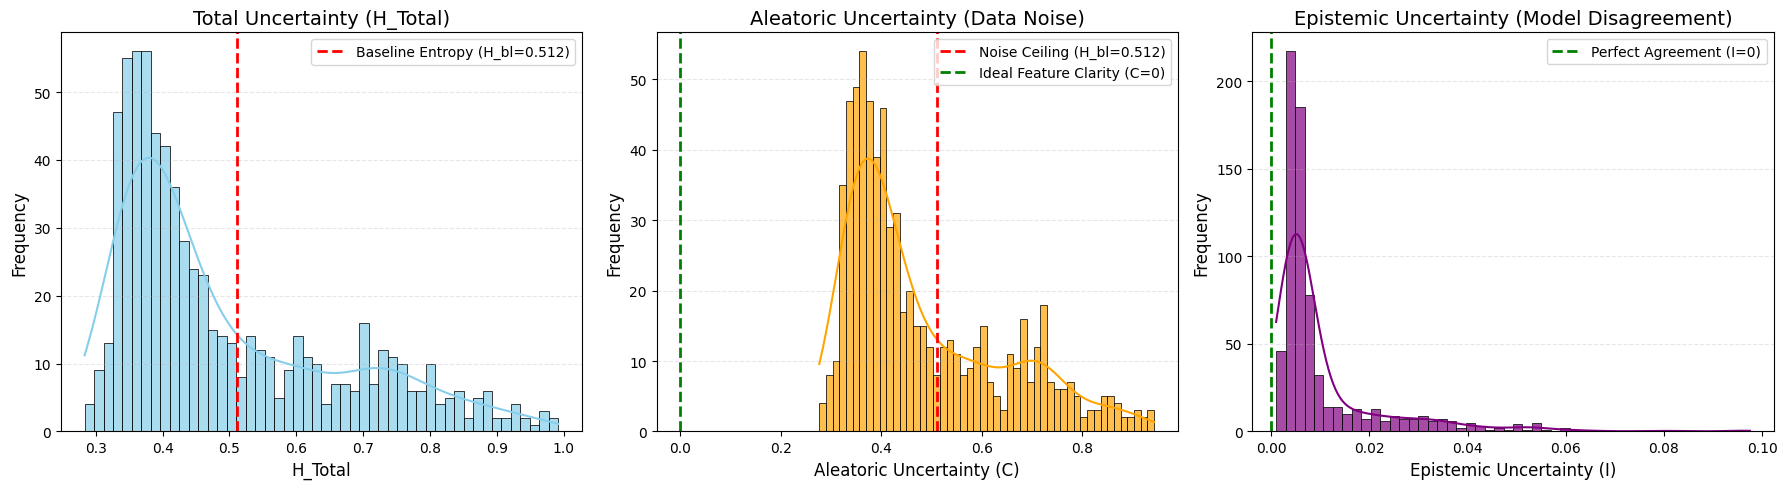

In [3]:
# Compute uncertainties for the non-active patients at baseline


uncertainty_results = compute_uncertainties(probs_raw_df)

# Create an explicit copy to avoid SettingWithCopyWarning
patients_stats_copy = patients_stats.copy()

# 2. Add the results to your main stats table
patients_stats_copy['H_Total'] = uncertainty_results['H_Total']
patients_stats_copy['C_Aleatoric'] = uncertainty_results['C_Aleatoric']
patients_stats_copy['I_Epistemic'] = uncertainty_results['I_Epistemic']


# Compute the baseline risk (mean of probs_cal across all folds) for each patient and its uncertainty value 
proportion_positive = all_patients['label'].sum() / len(all_patients)
H_bl = -(proportion_positive * np.log2(proportion_positive + 1e-12) +
         (1 - proportion_positive) * np.log2(1 - proportion_positive + 1e-12))
print("Baseline entropy:", H_bl)



plot_uncertainty_distributions(
     patients_stats_copy, 
     H_bl, 
     #save_path='../results/uncertainty/plots/uncertainty_distributions.png'
 )

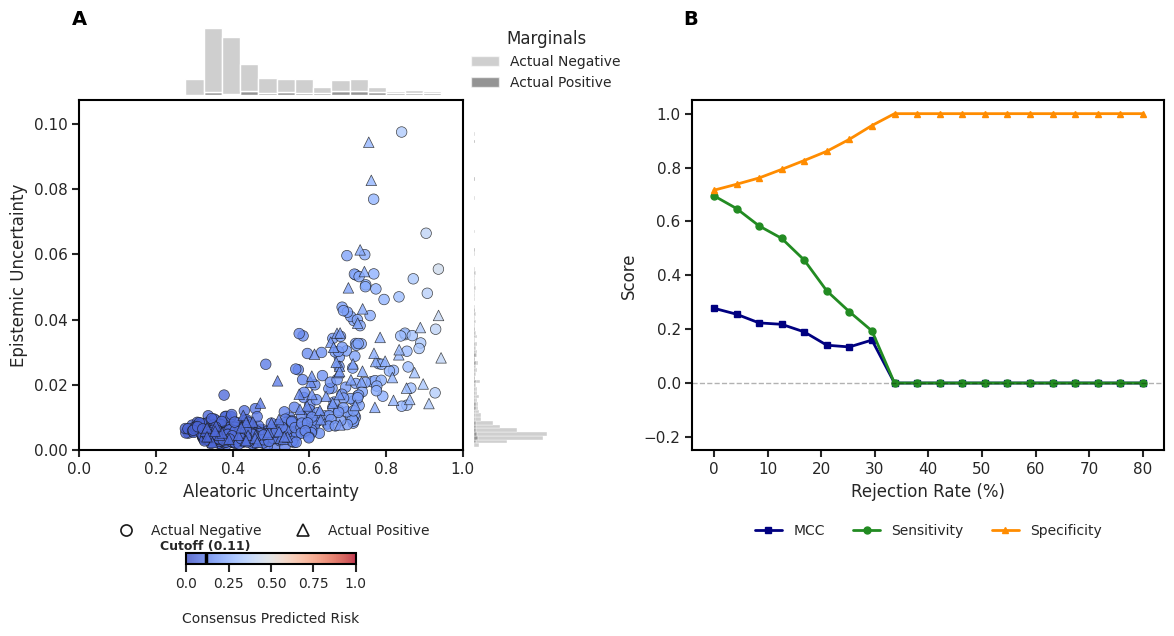

In [4]:
plot_combined_uncertainty_analysis(patients_stats_copy, all_patients['label'])

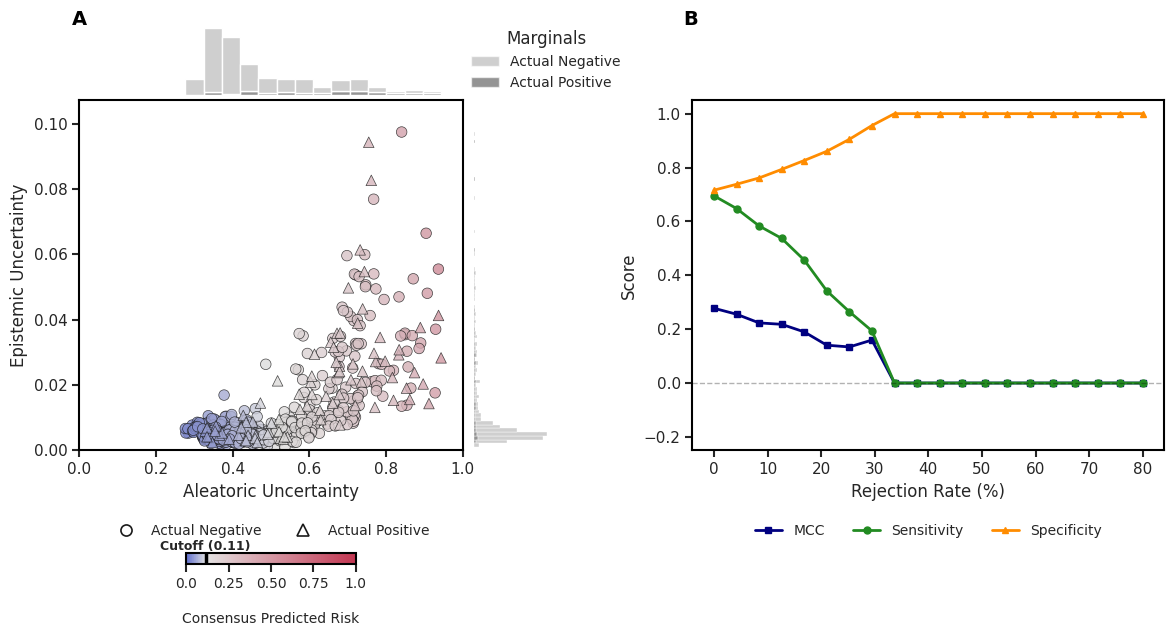

In [5]:
from lib.plots import plot_combined_uncertainty_analysis_v2


plot_combined_uncertainty_analysis_v2(patients_stats_copy,all_patients['label'])

## Explore clinical data through GMM analysis
No clear separation between patients. The two scores do not agree on the number of clusters. For this MS dataset we are going to skip the GMM analysis and rejection and move on to Conditioned Classification Rejection Curves (CCRC).

Number of original clinical features: 32
Optimal PCs according to the Kaiser Rule: 13

Top 5 Eigenvalues:
[3.54 2.69 2.57 2.04 1.76]


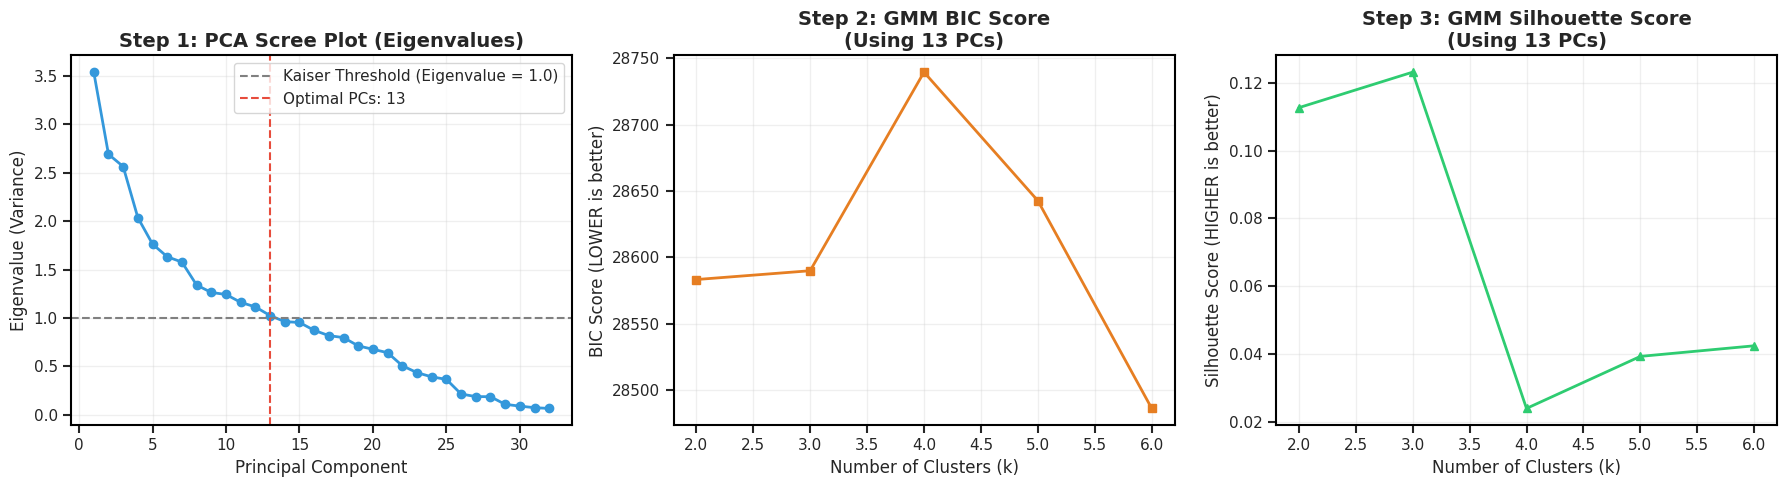


--- Optimization Results ---
1. Optimal PCs retained (Kaiser Rule, Eigenvalue > 1.0): 13
2. Best GMM model according to BIC (lowest complexity penalty): k = 6
3. Best GMM model according to Silhouette (highest separation): k = 3


In [6]:
from lib.clustering import optimize_pca_and_gmm_kaiser


optimize_pca_and_gmm_kaiser(X_clinical = all_patients.drop(['label'], axis=1), max_clusters=6)

## Conditioned Classification Rejection Curves (CCRC)

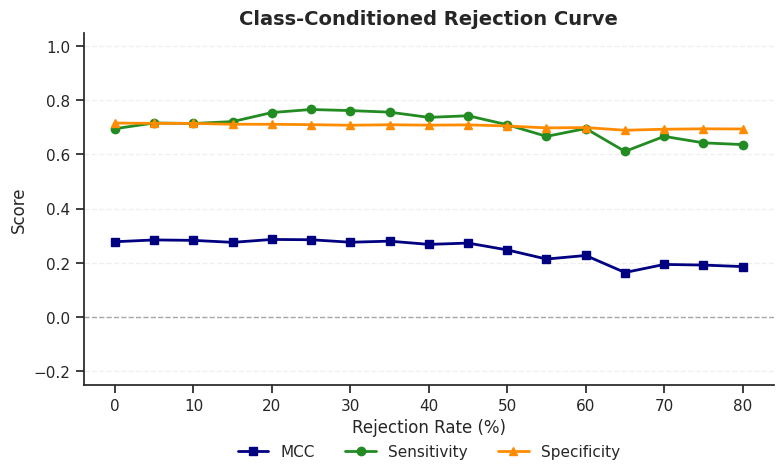

GLOBAL CLASS-CONDITIONED REJECTION: METRICS EVOLUTION
 Rejection (%)  Total Kept  TP  FP  TN  FN   MCC  Sensitivity  Specificity
             0         719  57 181 456  25 0.278        0.695        0.716
             5         684  53 174 436  21 0.284        0.716        0.715
            10         648  50 165 413  20 0.283        0.714        0.715
            15         612  44 159 392  17 0.275        0.721        0.711
            20         576  40 151 372  13 0.286        0.755        0.711
            25         540  36 143 350  11 0.285        0.766        0.710
            30         504  32 135 327  10 0.276        0.762        0.708
            35         468  31 124 303  10 0.280        0.756        0.710
            40         432  28 115 279  10 0.268        0.737        0.708
            45         396  26 105 256   9 0.273        0.743        0.709
            50         360  22  97 232   9 0.247        0.710        0.705
            55         325  18  90 208   9 0.2

In [7]:
from lib.plots import plot_class_conditioned_rejection_curve


optimal_threshold = all_patients['label'].mean()

class_cond_results = plot_class_conditioned_rejection_curve(
    patients_stats_copy, 
    threshold=optimal_threshold, 
    uncertainty_col='H_Total',
    rates=np.linspace(0, 80, 17)
)

### Confusion matrix evolution analysis


Standard global rejection frameworks fail in clinical datasets because predicting the onset of a future disease (Class 1) is inherently noisier than diagnosing baseline stability (Class 0). This Asymmetric Aleatoric Uncertainty causes standard algorithms to disproportionately delete the positive class, crashing the Sensitivity to zero.

By implementing Class-Conditioned Rejection tied to the baseline prior, we successfully decoupled the rejection threshold from this asymmetric noise.

Dataset 1 (The Imbalanced Cohort | Prior ~0.11) -> The "Rescue" Mechanism

Observation: The baseline model struggles with the rare minority class (Sens: ~0.69, MCC: 0.27).

Impact: Class-Conditioned Rejection actively rescues the model. By dropping the top 25% of uncertain patients proportionally from both predicted classes, Sensitivity actually rises to ~0.76 and holds steady. We successfully deferred a quarter of the most ambiguous patients without artificially collapsing the rare disease class.

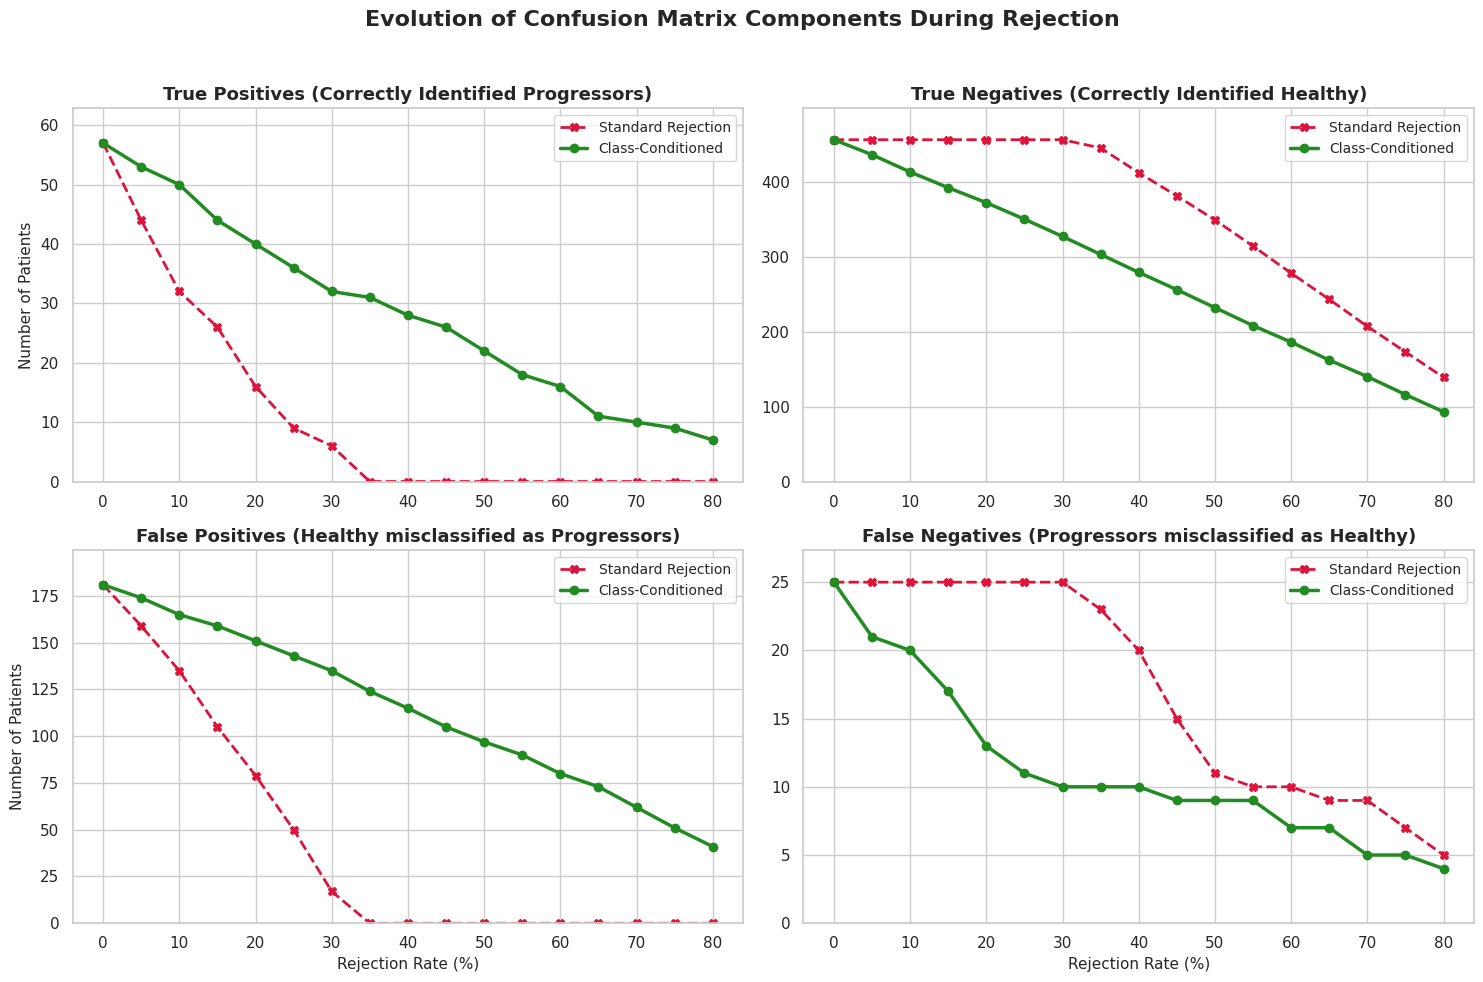

In [8]:

# Example Call:
from lib.plots import plot_comprehensive_rejection_dashboard


optimal_threshold = patients_stats_copy['label'].mean()
dashboard_results = plot_comprehensive_rejection_dashboard(patients_stats_copy, threshold=optimal_threshold)

In [9]:

from lib.utils import extract_and_analyze_rejection


optimal_threshold = patients_stats_copy['label'].mean()

# Extract the patients at a 25% rejection rate
kept_df, removed_df, uncertainty_stats = extract_and_analyze_rejection(
     patients_stats_copy, 
     prior_threshold=optimal_threshold, 
     rate=25, 
     method='class_conditioned',
     sort_col='H_Total',
     uncertainty_cols=['H_Total', 'C_Aleatoric', 'I_Epistemic', 'sigma']
)

REJECTION AUDIT: CLASS_CONDITIONED @ 25%
Total Cohort:    719 patients
Total Kept:      540 patients
Total Removed:   179 patients
--------------------------------------------------------------------------------
UNCERTAINTY PROFILE COMPARISON:
     Metric  Kept_Profile Removed_Profile P_Value
    H_Total 0.459 ± 0.139   0.593 ± 0.193  <0.001
C_Aleatoric 0.450 ± 0.133   0.578 ± 0.178  <0.001
I_Epistemic 0.009 ± 0.009   0.015 ± 0.019   0.019
      sigma 0.032 ± 0.021   0.049 ± 0.037  <0.001


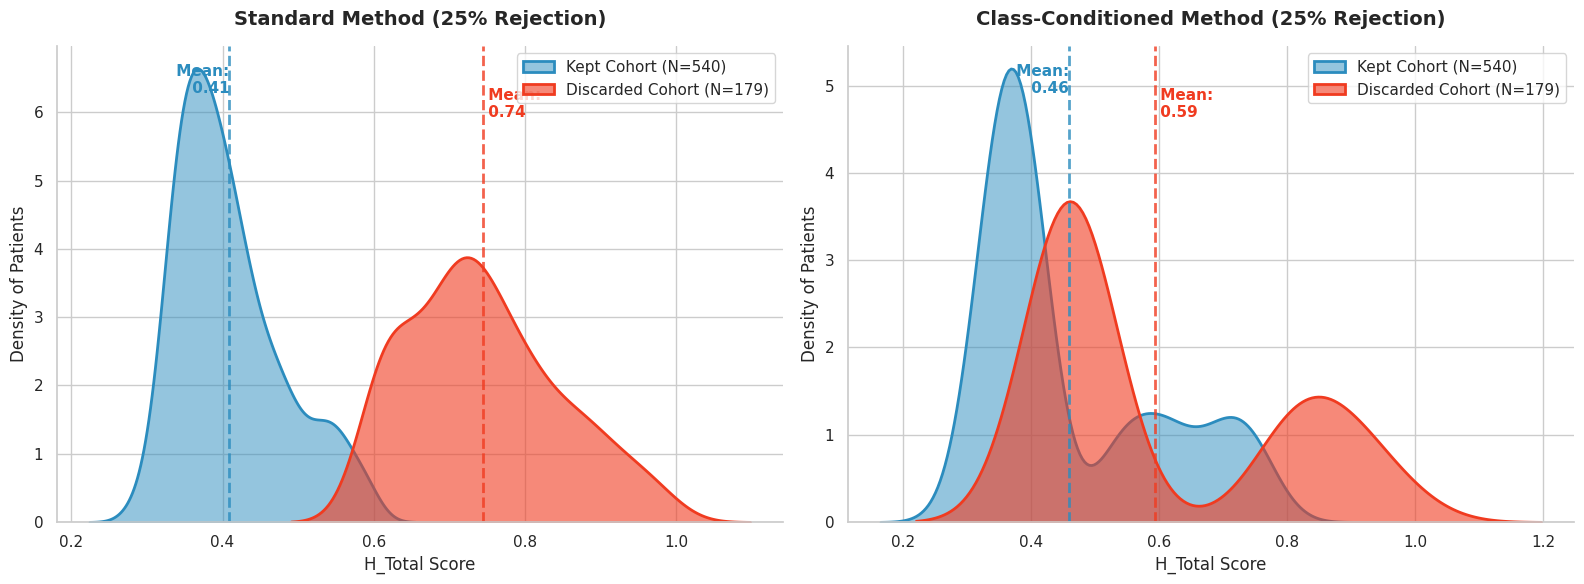

In [ ]:


from lib.plots import plot_side_by_side_distributions


# --- Example Usage ---
optimal_threshold = patients_stats_copy['label'].mean()
plot_side_by_side_distributions(patients_stats_copy, threshold=optimal_threshold, rate=25)

1. The Left Plot: The "Blind Guillotine"
Look at the Standard Method on the left. There is a rigid, vertical invisible wall right around H_Total = 0.55.

The algorithm blindly looked at the dataset, drew a line, and chopped off everything to the right.

As we established, the minority class (Progressors) naturally lives on the right side of this chart because their disease is biologically harder to predict. By dropping the guillotine here, the standard method is just indiscriminately wiping out your True Positives.

2. The Right Plot: The "Intelligent Scalpel" (The Breakthrough)
This plot is everything you want to see. Look at the massive structural changes:

The Red Peak shifted LEFT: In the standard method, discarded patients averaged 0.74. Here, there is a massive red spike of discarded patients sitting all the way down at ~0.45. What is the algorithm doing? It is looking at the Majority Class (Healthy) and saying: "You are supposed to be easy to predict. An uncertainty of 0.45 is suspiciously high for a healthy patient. You are discarded." It is actively cleaning out the noisy False Positives!

The Blue Tail shifted RIGHT: Look at the blue curve (Kept Cohort). It now has a secondary hump stretching all the way past 0.8! What is the algorithm doing here? It is looking at the Minority Class (Progressors) and saying: "You have an uncertainty of 0.75, which is high, but predicting the future is hard. Compared to your peers, you are actually one of our best positive predictions. You are kept." ### The Verdict
You have visually proven that your Class-Conditioned method protects the minority class. By allowing the distributions to overlap, you demonstrated that absolute uncertainty is not a fair metric for rejection in imbalanced clinical data. You have to judge a prediction's uncertainty relative to the baseline difficulty of its class.